# Business Problem:
A global e-commerce company operating across multiple regions manages end to end order fulfillment, including shipping and delivery , for products like sporting goods. THe company is facing inconsistent delivery performance, where actual shipping items often devate from scheduled timelines, leading to late deliveries and unpredictable order probability.

# Desired outcome:
The goal is to analyze delivery operations, identity bottlenecks, and build a predictive system to reduce delays, optimize shipping decisions, and improve overall profitability and efficiency.

In [126]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import matplotlib.ticker as ticker
import matplotlib.cm as cm
from warnings import filterwarnings
filterwarnings('ignore')

In [127]:
# set professional color theme
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("viridis")
viridis_colors = cm.viridis(np.linspace(0, 1, 5))
primary_color = viridis_colors[0]
secondary_color = viridis_colors[1]
accent_color = viridis_colors[2]
danger_color = "#800000"
neutral_color = viridis_colors[4]
custom_palette = viridis_colors

In [128]:
df = pd.read_csv(r"C:\Users\prade\Downloads\DataCoSupplyChainDataset.csv",encoding = 'latin-1')

In [129]:
df

,Type,Days for shipping (real),Days for shipment (scheduled),Benefit per order,Sales per customer,Delivery Status,Late_delivery_risk,Category Id,Category Name,Customer City,...,Order Zipcode,Product Card Id,Product Category Id,Product Description,Product Image,Product Name,Product Price,Product Status,shipping date (DateOrders),Shipping Mode
0,DEBIT,3,4,91.250000,314.640015,Advance shipping,0,73,Sporting Goods,Caguas,...,NaN,1360,73,NaN,http://images.acmesports.sports/Smart+watch,Smart watch,327.750000,0,2/3/2018 22:56,Standard Class
1,TRANSFER,5,4,-249.089996,311.359985,Late delivery,1,73,Sporting Goods,Caguas,...,NaN,1360,73,NaN,http://images.acmesports.sports/Smart+watch,Smart watch,327.750000,0,1/18/2018 12:27,Standard Class
2,CASH,4,4,-247.779999,309.720001,Shipping on time,0,73,Sporting Goods,San Jose,...,NaN,1360,73,NaN,http://images.acmesports.sports/Smart+watch,Smart watch,327.750000,0,1/17/2018 12:06,Standard Class
3,DEBIT,3,4,22.860001,304.809998,Advance shipping,0,73,Sporting Goods,Los Angeles,...,NaN,1360,73,NaN,http://images.acmesports.sports/Smart+watch,Smart watch,327.750000,0,1/16/2018 11:45,Standard Class
4,PAYMENT,2,4,134.210007,298.250000,Advance shipping,0,73,Sporting Goods,Caguas,...,NaN,1360,73,NaN,http://images.acmesports.sports/Smart+watch,Smart watch,327.750000,0,1/15/2018 11:24,Standard Class
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
180514,CASH,4,4,40.000000,399.980011,Shipping on time,0,45,Fishing,Brooklyn,...,NaN,1004,45,NaN,http://images.acmesports.sports/Field+%26+Stre...,Field & Stream Sportsman 16 Gun Fire Safe,399.980011,0,1/20/2016 3:40,Standard Class
180515,DEBIT,3,2,-613.770019,395.980011,Late delivery,1,45,Fishing,Bakersfield,...,NaN,1004,45,NaN,http://images.acmesports.sports/Field+%26+Stre...,Field & Stream Sportsman 16 Gun Fire Safe,399.980011,0,1/19/2016 1:34,Second Class
180516,TRANSFER,5,4,141.110001,391.980011,Late delivery,1,45,Fishing,Bristol,...,NaN,1004,45,NaN,http://images.acmesports.sports/Field+%26+Stre...,Field & Stream Sportsman 16 Gun Fire Safe,399.980011,0,1/20/2016 21:00,Standard Class
180517,PAYMENT,3,4,186.229996,387.980011,Advance shipping,0,45,Fishing,Caguas,...,NaN,1004,45,NaN,http://images.acmesports.sports/Field+%26+Stre...,Field & Stream Sportsman 16 Gun Fire Safe,399.980011,0,1/18/2016 20:18,Standard Class


# Exploratory Data Analysis

In [131]:
# overview
print("rows, columns:",df.shape)
print("\ncolumns:")
print(df.columns.tolist())
print("\nNum Duplicate:",df.duplicated().sum())
print("\nMsiising Values (top 20):")
print(df.isna().sum().sort_values(ascending = False).head(10))

rows, columns: (180519, 53)

columns:
['Type', 'Days for shipping (real)', 'Days for shipment (scheduled)', 'Benefit per order', 'Sales per customer', 'Delivery Status', 'Late_delivery_risk', 'Category Id', 'Category Name', 'Customer City', 'Customer Country', 'Customer Email', 'Customer Fname', 'Customer Id', 'Customer Lname', 'Customer Password', 'Customer Segment', 'Customer State', 'Customer Street', 'Customer Zipcode', 'Department Id', 'Department Name', 'Latitude', 'Longitude', 'Market', 'Order City', 'Order Country', 'Order Customer Id', 'order date (DateOrders)', 'Order Id', 'Order Item Cardprod Id', 'Order Item Discount', 'Order Item Discount Rate', 'Order Item Id', 'Order Item Product Price', 'Order Item Profit Ratio', 'Order Item Quantity', 'Sales', 'Order Item Total', 'Order Profit Per Order', 'Order Region', 'Order State', 'Order Status', 'Order Zipcode', 'Product Card Id', 'Product Category Id', 'Product Description', 'Product Image', 'Product Name', 'Product Price', 'Pro

In [132]:
# Data cleaning
columns_to_drop = [
    'Product Description',
    'Product Image',
    'Customer Email',
    'Customer Password',
    'Customer Fname',
    'Customer Lname',
    'Customer Street',
    'Customer Zipcode',
    'Order Zipcode',
    'Longitude',
    'Latitude',
    'Order Item Cardprod Id',
    'Order Item Discount',
    'Order Item Discount Rate',
    'Order Item Id',
    'Order Item Product Price',
    'Order Item Quantity',
    'Order Item Total',
    'Category Id',
    'Department Id',
    'Order Id',
    'Order Customer Id',
    'Customer Id',
    'Product Card Id',
    'Product Category Id',
    'Benefit per order',
    'Product Status',
    'Customer City',
    'Order City',
    'Order Country',
    'Order State',
    'Customer State',
    'Market']

# dropping Columns that are either fully missing, redundant, or have only one value (and thus no variance)
df = df.drop(columns = columns_to_drop)

# Removing Cancelled orders since they are not relevant for delivery time analysis and may have different patterns than completed orders
df = df[df["Delivery Status"] != "Shipping Cancelled"]

# Standard date conversion
for i in ["order date (DateOrders)", "shipping date (DateOrders)"]:
    df[i] = pd.to_datetime(df[i], errors = 'coerce', dayfirst = False)

# After data cleaning lets check the overview again to see how the dataset has changed
print("rows, columns:",df.shape)
print("\nMsiising Values (top 20):")
print(df.isna().sum().sort_values(ascending = False).head(5))

rows, columns: (180519, 20)

Msiising Values (top 20):
Type                          0
Days for shipping (real)      0
shipping date (DateOrders)    0
Product Price                 0
Product Name                  0
dtype: int64


In [133]:
df.head()

,Type,Days for shipping (real),Days for shipment (scheduled),Sales per customer,Delivery Status,Late_delivery_risk,Category Name,Customer Country,Customer Segment,Department Name,order date (DateOrders),Order Item Profit Ratio,Sales,Order Profit Per Order,Order Region,Order Status,Product Name,Product Price,shipping date (DateOrders),Shipping Mode
0,DEBIT,3,4,314.640015,Advance shipping,0,Sporting Goods,Puerto Rico,Consumer,Fitness,2018-01-31 22:56:00,0.29,327.75,91.250000,Southeast Asia,COMPLETE,Smart watch,327.75,2018-02-03 22:56:00,Standard Class
1,TRANSFER,5,4,311.359985,Late delivery,1,Sporting Goods,Puerto Rico,Consumer,Fitness,2018-01-13 12:27:00,-0.80,327.75,-249.089996,South Asia,PENDING,Smart watch,327.75,2018-01-18 12:27:00,Standard Class
2,CASH,4,4,309.720001,Shipping on time,0,Sporting Goods,EE. UU.,Consumer,Fitness,2018-01-13 12:06:00,-0.80,327.75,-247.779999,South Asia,CLOSED,Smart watch,327.75,2018-01-17 12:06:00,Standard Class
3,DEBIT,3,4,304.809998,Advance shipping,0,Sporting Goods,EE. UU.,Home Office,Fitness,2018-01-13 11:45:00,0.08,327.75,22.860001,Oceania,COMPLETE,Smart watch,327.75,2018-01-16 11:45:00,Standard Class
4,PAYMENT,2,4,298.250000,Advance shipping,0,Sporting Goods,Puerto Rico,Corporate,Fitness,2018-01-13 11:24:00,0.45,327.75,134.210007,Oceania,PENDING_PAYMENT,Smart watch,327.75,2018-01-15 11:24:00,Standard Class


In [134]:
# Value counts for categorical columns with low cadinality
for i in df.columns:
    if df[i].nunique() < 10:
        print(f'\n{i} value counts:')
        print(df[i].value_counts())


Type value counts:
Type
DEBIT       69295
TRANSFER    49883
PAYMENT     41725
CASH        19616
Name: count, dtype: int64

Days for shipping (real) value counts:
Days for shipping (real)
2    56618
3    28765
6    28723
4    28513
5    28163
0     5080
1     4657
Name: count, dtype: int64

Days for shipment (scheduled) value counts:
Days for shipment (scheduled)
4    107752
2     35216
1     27814
0      9737
Name: count, dtype: int64

Delivery Status value counts:
Delivery Status
Late delivery        98977
Advance shipping     41592
Shipping on time     32196
Shipping canceled     7754
Name: count, dtype: int64

Late_delivery_risk value counts:
Late_delivery_risk
1    98977
0    81542
Name: count, dtype: int64

Customer Country value counts:
Customer Country
EE. UU.        111146
Puerto Rico     69373
Name: count, dtype: int64

Customer Segment value counts:
Customer Segment
Consumer       93504
Corporate      54789
Home Office    32226
Name: count, dtype: int64

Order Status value c

In [135]:
# calculating order processing time and delay
df['Order Processing Time'] = (df['shipping date (DateOrders)'] - df['order date (DateOrders)']).dt.days

df['Delay'] = df['Order Processing Time'] - df['Days for shipment (scheduled)']

df['Is_Delayed'] = df['Delay'] > 0

df['order_month'] = df['order date (DateOrders)'].dt.month

df['order_day'] = df['order date (DateOrders)'].dt.day_name()

df['order_hour'] = df['order date (DateOrders)'].dt.hour

df.describe()

,Days for shipping (real),Days for shipment (scheduled),Sales per customer,Late_delivery_risk,order date (DateOrders),Order Item Profit Ratio,Sales,Order Profit Per Order,Product Price,shipping date (DateOrders),Order Processing Time,Delay,order_month,order_hour
count,180519.000000,180519.000000,180519.000000,180519.000000,180519,180519.000000,180519.000000,180519.000000,180519.000000,180519,180519.000000,180519.000000,180519.000000,180519.000000
mean,3.497654,2.931847,183.107609,0.548291,2016-06-12 17:47:04.669868544,0.120647,203.772096,21.974989,141.232550,2016-06-16 05:45:23.202433024,3.471856,0.540010,6.235449,11.483689
min,0.000000,0.000000,7.490000,0.000000,2015-01-01 00:00:00,-2.750000,9.990000,-4274.979980,9.990000,2015-01-03 00:00:00,0.000000,-2.000000,1.000000,0.000000
25%,2.000000,2.000000,104.379997,0.000000,2015-09-21 13:49:00,0.080000,119.980003,7.000000,50.000000,2015-09-25 06:59:00,2.000000,0.000000,3.000000,5.000000
50%,3.000000,4.000000,163.990005,1.000000,2016-06-11 13:06:00,0.270000,199.919998,31.520000,59.990002,2016-06-15 08:32:00,3.000000,1.000000,6.000000,11.000000
75%,5.000000,4.000000,247.399994,1.000000,2017-03-01 08:42:00,0.360000,299.950012,64.800003,199.990005,2017-03-04 21:29:00,5.000000,1.000000,9.000000,17.000000
max,6.000000,4.000000,1939.989990,1.000000,2018-01-31 23:38:00,0.500000,1999.989990,911.799988,1999.989990,2018-02-06 22:14:00,6.000000,4.000000,12.000000,23.000000
std,1.623722,1.374449,120.043670,0.497664,NaN,0.466796,132.273077,104.433526,139.732492,NaN,1.670471,1.491881,3.403571,6.923006


In [136]:
df["Is_Delayed"].value_counts()

Is_Delayed
True     98743
False    81776
Name: count, dtype: int64

In [137]:
df.columns

Index(['Type', 'Days for shipping (real)', 'Days for shipment (scheduled)',
       'Sales per customer', 'Delivery Status', 'Late_delivery_risk',
       'Category Name', 'Customer Country', 'Customer Segment',
       'Department Name', 'order date (DateOrders)', 'Order Item Profit Ratio',
       'Sales', 'Order Profit Per Order', 'Order Region', 'Order Status',
       'Product Name', 'Product Price', 'shipping date (DateOrders)',
       'Shipping Mode', 'Order Processing Time', 'Delay', 'Is_Delayed',
       'order_month', 'order_day', 'order_hour'],
      dtype='object')

In [138]:
# Profitability Flag based on Order Profit Per Order
df['Profitability Flag'] = np.where(df['Order Profit Per Order'] > 0, 'Profit',np.where(df['Order Profit Per Order'] < 0, 'Loss', 'Break-even'))

df['Profitability Flag'].value_counts()

Profitability Flag
Profit        145558
Loss           33784
Break-even      1177
Name: count, dtype: int64

In [139]:
df["Profitability Flag"].value_counts(normalize=True)

Profitability Flag
Profit        0.806331
Loss          0.187149
Break-even    0.006520
Name: proportion, dtype: float64

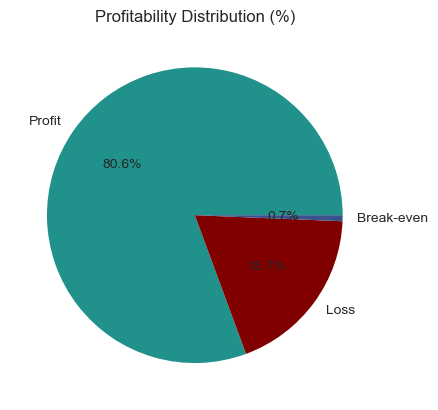

In [140]:
# visualization of profitability distribution
profit_counts = df["Profitability Flag"].value_counts(normalize=True)*100
profit_counts.plot(kind= "pie", autopct = "%1.1f%%", colors = [accent_color, danger_color, secondary_color])
plt.ylabel('')
plt.title('Profitability Distribution (%)')
plt.show()

In [141]:
def format_func(value):
    if value >= 1e6:
        return f'{value/1e6:.1f}M $'
    elif value >= 1e3:
        return f'{value/1e3:.1f}K $'
    else:
        return f'{value:.0f} $'


delayed_df = df[df['Delay'] > 0]

metrics = {}
metrics['Total Orders'] = len(df)
metrics['Late Deliveries'] = len(delayed_df)
metrics['90% Delay (days)'] = delayed_df['Delay'].quantile(0.90)
metrics['On time Delivery %'] = (1 - float(metrics['Late Deliveries']) / metrics['Total Orders']) * 100
metrics['Late Delivery %'] = float(metrics['Late Deliveries']) / metrics['Total Orders'] * 100
metrics['Total Profit'] = format_func(df.loc[df['Order Profit Per Order'] > 0, 'Order Profit Per Order'].sum())
metrics['Total Loss due to delays'] = format_func(df.loc[df['Delay'] > 0, 'Order Profit Per Order'].sum())

print("\n--- Business KPIs ---\n")
for k, v in metrics.items():
    if isinstance(v, float):
        print(f"{k}: {v:.2f}")
    else:
        print(f"{k}: {v}")


--- Business KPIs ---

Total Orders: 180519
Late Deliveries: 98743
90% Delay (days): 3.00
On time Delivery %: 45.30
Late Delivery %: 54.70
Total Profit: 7.9M $
Total Loss due to delays: 2.1M $


 # Profitability vs Delivery Time Analysis

In [143]:
profit_metrics = (df.groupby('Delay')['Order Profit Per Order'].agg(
    mean_profit = "mean",
    total_profit = "sum",
    order_count = "count"
).reset_index()
                 )


In [144]:
profit_metrics

,Delay,mean_profit,total_profit,order_count
0,-2,23.423528,5.074942e+05,21666
1,-1,21.516997,4.669188e+05,21700
2,0,22.044854,8.467429e+05,38410
3,1,22.225592,1.244411e+06,55990
4,2,21.246239,6.101495e+05,28718
5,3,19.941130,1.406248e+05,7052
6,4,21.561202,1.505619e+05,6983


In [145]:
delay_distribution = (df["Delay"].value_counts(normalize=True).sort_index()*100).reset_index()

In [146]:
delay_distribution

,Delay,proportion
0,-2,12.002061
1,-1,12.020895
2,0,21.277539
3,1,31.016126
4,2,15.908575
5,3,3.906514
6,4,3.868291



Profit Metrics by Delay Day:


,Delay,mean_profit,total_profit,order_count
0,-2,23.4,507494.2,21666
1,-1,21.5,466918.8,21700
2,0,22.0,846742.9,38410
3,1,22.2,1244410.9,55990
4,2,21.2,610149.5,28718
5,3,19.9,140624.8,7052
6,4,21.6,150561.9,6983



Delay Distribution (%):


,Delay_Days,Percentage
0,-2,12.002061
1,-1,12.020895
2,0,21.277539
3,1,31.016126
4,2,15.908575
5,3,3.906514
6,4,3.868291


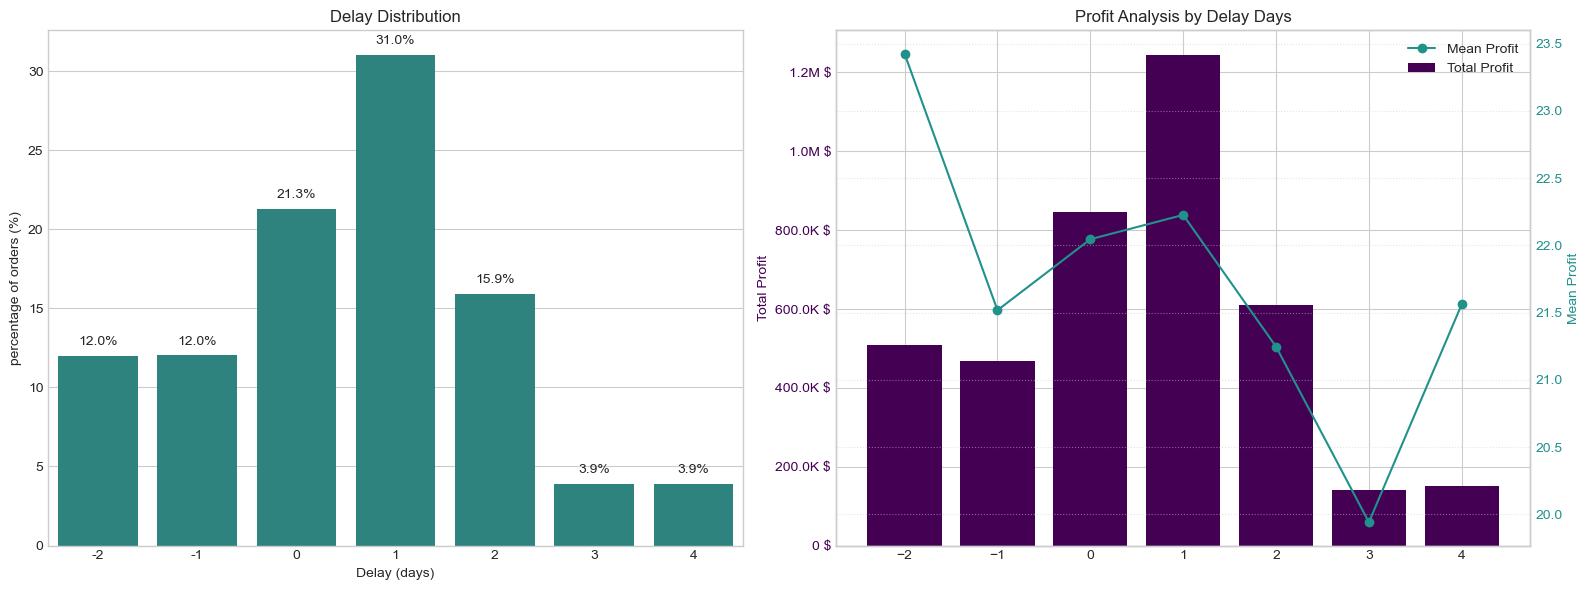

In [147]:
delay_distribution.columns = ['Delay_Days', 'Percentage']

print("\nProfit Metrics by Delay Day:")
display(profit_metrics.round(1))

print("\nDelay Distribution (%):")
display(delay_distribution)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# First subplot: Delay Distribution
sns.barplot(x='Delay_Days', y='Percentage', data=delay_distribution, color=accent_color, ax=ax1)
ax1.set_title('Delay Distribution')
ax1.set_xlabel('Delay (days)')
ax1.set_ylabel('percentage of orders (%)')

# percentage text on bars
for bar in ax1.patches:
    height = bar.get_height()
    ax1.text(
        bar.get_x() + bar.get_width() / 2,
        height + 0.5,
        f'{height:.1f}%',
        ha='center',
        va='bottom'
    )

# Second subplot: Profit Analysis by Delay Days
ax2.set_ylabel('Total Profit', color=primary_color)
ax2.bar(profit_metrics['Delay'], profit_metrics['total_profit'], color=primary_color, label='Total Profit')
ax2.tick_params(axis='y', labelcolor=primary_color)

ax3 = ax2.twinx()
ax3.set_xlabel("Delay Days")
ax3.set_ylabel("Mean Profit", color = accent_color)
ax3.plot(profit_metrics["Delay"], profit_metrics["mean_profit"], marker = 'o', color = accent_color,label = "Mean Profit")
ax3.tick_params(axis='y', labelcolor = accent_color)

# Format total profit axis to K $, M $
def format_func(value, tick_number):
    if value >= 1e6:
        return f'{value/1e6:.1f}M $'
    elif value >= 1e3:
        return f'{value/1e3:.1f}K $'
    else:
        return f'{value:.0f} $'


ax2.yaxis.set_major_formatter(ticker.FuncFormatter(format_func))

ax3.set_title("Profit Analysis by Delay Days")

lines, labels = ax3.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax3.legend(lines + lines2, labels + labels2, loc='upper right')

ax3.grid(True, linestyle=':', alpha=0.5)

plt.tight_layout()
plt.show()

# Bottleneck Detection

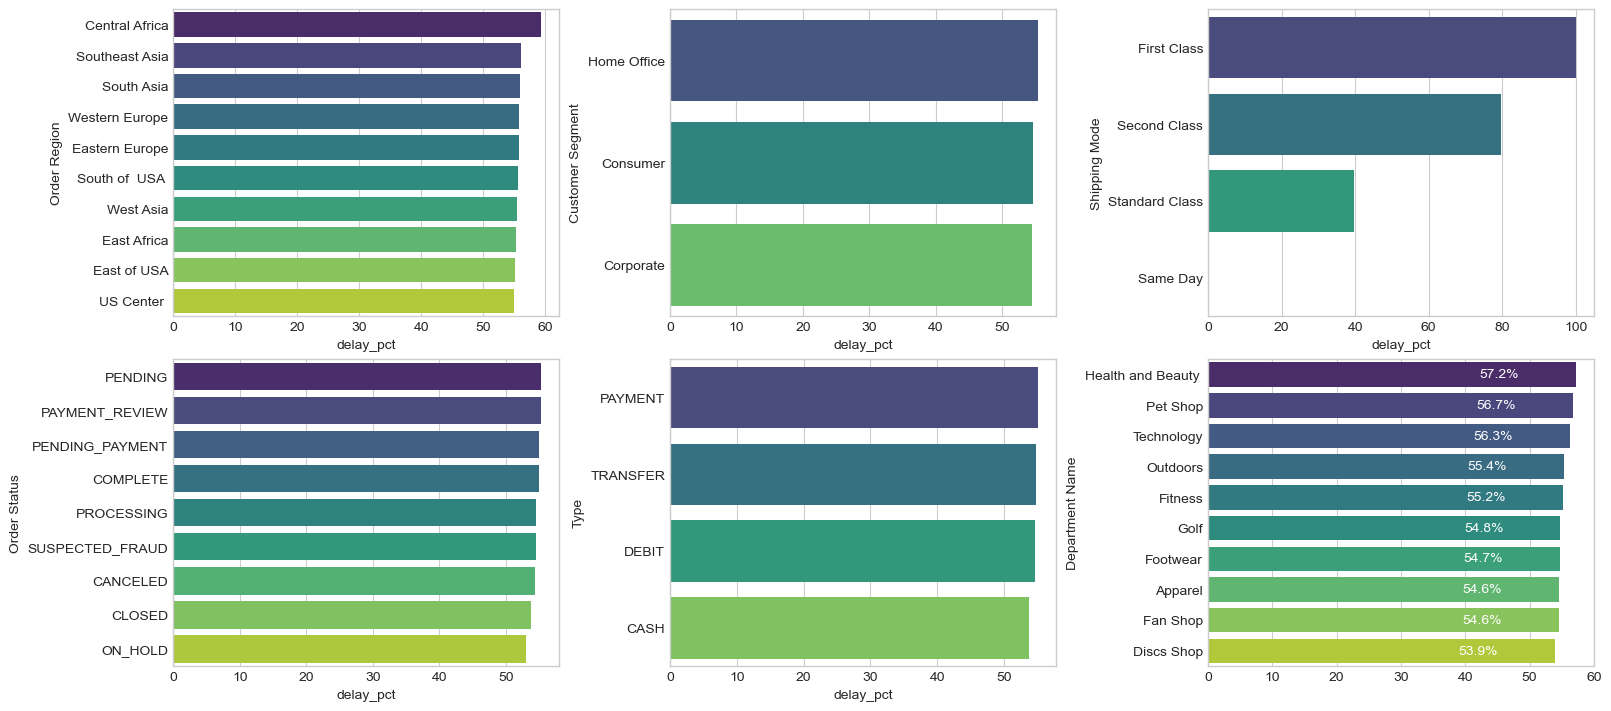

In [170]:
def compute_delay_pct_by_category(category):
    cat_df = df.groupby(category).agg(
        total_orders=('Delay', 'count'),
        late_orders=('Is_Delayed', 'sum')
    ).reset_index()

    cat_df['delay_pct'] = cat_df['late_orders'] / cat_df['total_orders'] * 100
    cat_df = cat_df.sort_values('delay_pct', ascending=False).head(10)

    return cat_df


categories = [
    'Order Region',
    'Customer Segment',
    'Shipping Mode',
    'Order Status',
    'Type',
    'Department Name'
]

fig, axes = plt.subplots(2, 3, figsize=(16, 7), constrained_layout=True)
axes = axes.flatten()

for ax, category in zip(axes, categories):
    cat_df = compute_delay_pct_by_category(category)

    sns.barplot(
        data=cat_df,
        x='delay_pct',
        y=category,
        ax=ax,
        palette='viridis'
    )

ax.set_xlabel('')
ax.set_ylabel(category)

for i, row in cat_df.reset_index().iterrows():
    ax.text(
        row['delay_pct'] - 15,
        i,
        f"{row['delay_pct']:.1f}%",
        va='center',
        fontsize=10,
        color='white'
    )

plt.show()

In [172]:
def compute_delay_pct_by_category(category):
    cat_df = df.groupby(category).agg(
        total_orders=('Delay', 'count'),
        late_orders=('Is_Delayed', 'sum')
    ).reset_index()

    cat_df['delay_pct'] = cat_df['late_orders'] / cat_df['total_orders'] * 100
    cat_df = cat_df.sort_values('delay_pct', ascending=False).head(10)

    return cat_df

In [174]:
compute_delay_pct_by_category('Customer Segment')

,Customer Segment,total_orders,late_orders,delay_pct
2,Home Office,32226,17821,55.300068
0,Consumer,93504,51071,54.619054
1,Corporate,54789,29851,54.483564


# Root Cause Analysis

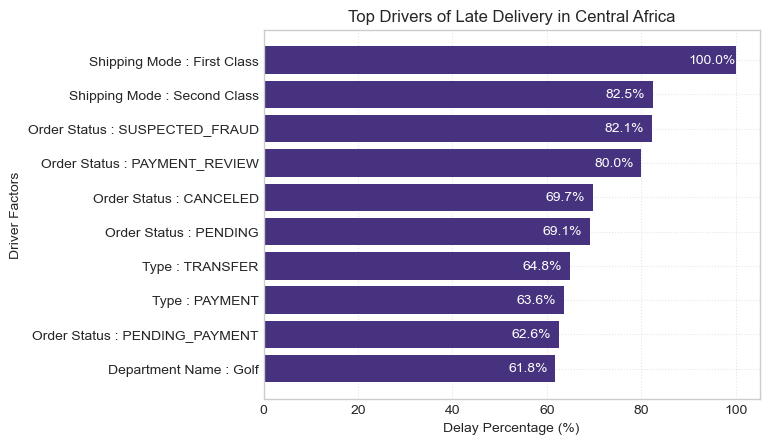

In [177]:
# Top drivers of late delivery by region

def top_drivers_for_region(region):
    df_region = df[df['Order Region'] == region].copy()

    drivers = ['Shipping Mode', 'Customer Segment', 'Department Name', 'Type', 'Order Status']

    all_factors = []

    for factor in drivers:
        temp = (
            df_region.groupby(factor)
            .agg(
                total_orders=('Delay', 'count'),
                late_orders=('Is_Delayed', 'sum'),
                avg_delay=('Delay', 'mean')
            )
            .reset_index()
        )

        temp['delay_pct'] = temp['late_orders'] / temp['total_orders'] * 100
        temp['Driver'] = factor
        temp['Factor_Level'] = factor + " : " + temp[factor].astype(str)

        all_factors.append(
            temp[['Driver', 'Factor_Level', 'delay_pct', 'avg_delay', 'total_orders']]
        )

    # Combine all drivers
    final_df = pd.concat(all_factors)

    # Top 10 drivers
    top_factors = final_df.sort_values('delay_pct', ascending=False).head(10)
    
    plt.figure()
    
    bars = plt.barh(top_factors['Factor_Level'], top_factors['delay_pct'])
    
    plt.xlabel("Delay Percentage (%)")
    plt.ylabel("Driver Factors")
    plt.title(f"Top Drivers of Late Delivery in {region}")
    plt.grid(True, linestyle=':', alpha=0.5)
    plt.gca().invert_yaxis()
    
    for bar in bars:
        width = bar.get_width()
        plt.text(
            width - 10,
            bar.get_y() + bar.get_height() / 2,
            f"{width:.1f}%",
            va='center',
            fontsize=10,
            color='white'
        )
    
    plt.show()

top_drivers_for_region('Central Africa')

In [179]:
# Delay % by Month, Day of Week, Hour

delay_by_month = (
    df.groupby('order_month')['Is_Delayed']
    .mean()
    .reset_index()
)
delay_by_month['delay_pct'] = delay_by_month['Is_Delayed'] * 100


delay_by_day = (
    df.groupby('order_day')['Is_Delayed']
    .mean()
    .reset_index()
)
delay_by_day['delay_pct'] = delay_by_day['Is_Delayed'] * 100


delay_by_hour = (
    df.groupby('order_hour')['Is_Delayed']
    .mean()
    .reset_index()
)
delay_by_hour['delay_pct'] = delay_by_hour['Is_Delayed'] * 100

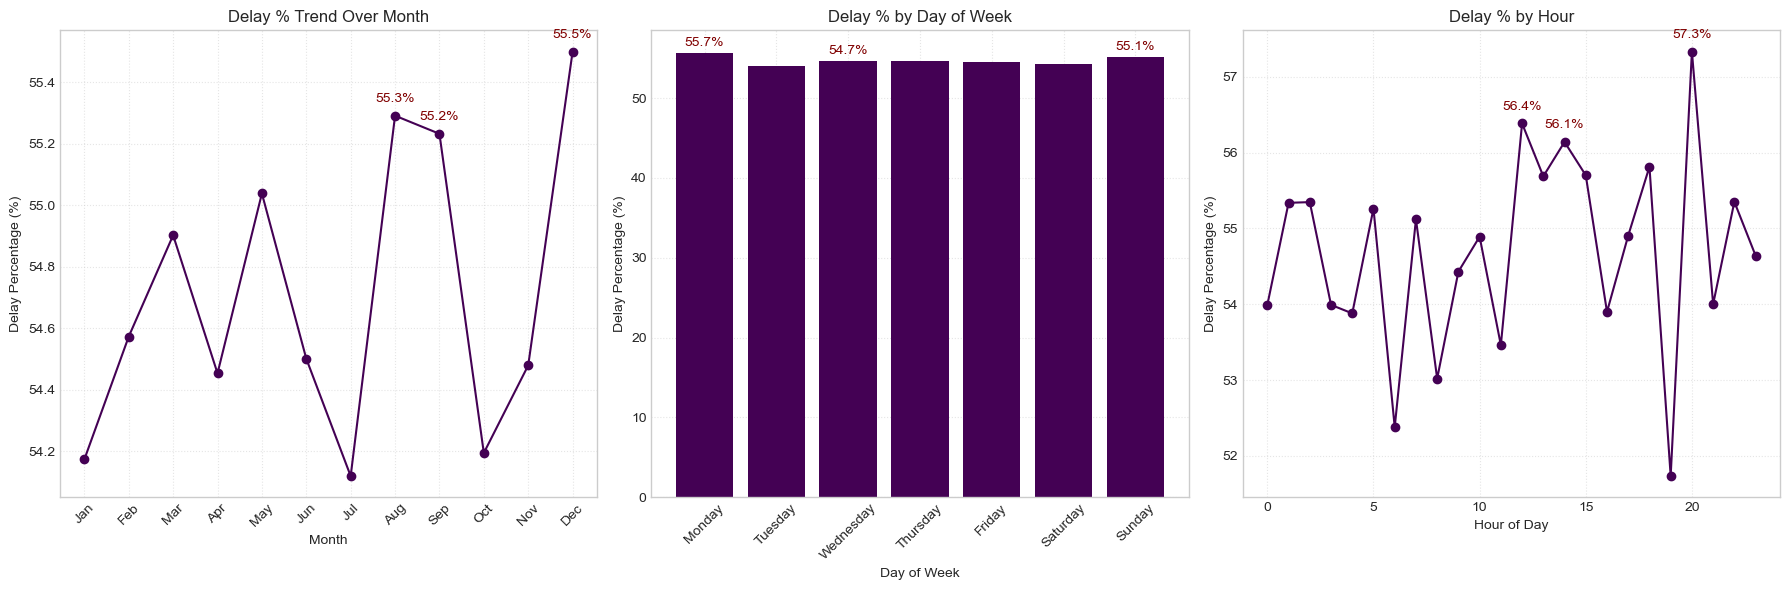

In [183]:
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(18, 6))

# Subplot 1: Delay % Trend Over Month
ax1.plot(delay_by_month['order_month'], delay_by_month['delay_pct'], marker='o', color=primary_color)
ax1.set_xticks(range(1, 13))
ax1.set_xticklabels(['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec'], rotation=45)
ax1.set_xlabel("Month")
ax1.set_ylabel("Delay Percentage (%)")
ax1.set_title("Delay % Trend Over Month")
ax1.grid(True, linestyle=':', alpha=0.5)

# Annotate top 3 highest
top3_month = delay_by_month.nlargest(3, 'delay_pct')
for _, row in top3_month.iterrows():
    ax1.annotate(f"{row['delay_pct']:.1f}%", (row['order_month'], row['delay_pct']),
                 textcoords="offset points", xytext=(0, 10), ha='center', fontsize=10, color=danger_color)

# Subplot 2: Delay % by Day of Week
day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
delay_by_day['order_day'] = pd.Categorical(delay_by_day['order_day'], categories=day_order, ordered=True)
delay_by_day = delay_by_day.sort_values('order_day')

ax2.bar(delay_by_day['order_day'], delay_by_day['delay_pct'], color=primary_color)
ax2.set_xticklabels(delay_by_day['order_day'], rotation=45)
ax2.set_xlabel("Day of Week")
ax2.set_ylabel("Delay Percentage (%)")
ax2.set_title("Delay % by Day of Week")
ax2.grid(True, linestyle=':', alpha=0.5)

# Annotate top 3 highest bars
top3_day = delay_by_day.nlargest(3, 'delay_pct')
for _, row in top3_day.iterrows():
    height = row['delay_pct']
    ax2.text(row['order_day'], height + 0.5, f'{height:.1f}%', ha='center', va='bottom', fontsize=10, color=danger_color)

# Subplot 3: Delay % by Hour
ax3.plot(delay_by_hour['order_hour'], delay_by_hour['delay_pct'], marker='o', color=primary_color)
ax3.set_xlabel("Hour of Day")
ax3.set_ylabel("Delay Percentage (%)")
ax3.set_title("Delay % by Hour")
ax3.grid(True, linestyle=':', alpha=0.5)

# Annotate top 3 highest
top3_hour = delay_by_hour.nlargest(3, 'delay_pct')
for _, row in top3_hour.iterrows():
    ax3.annotate(f"{row['delay_pct']:.1f}%", (row['order_hour'], row['delay_pct']),
                 textcoords="offset points", xytext=(0, 10), ha='center', fontsize=10, color=danger_color)

plt.tight_layout()
plt.show()

# Machine Learning Model

In [186]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score,precision_score,recall_score,classification_report
from sklearn.ensemble import RandomForestClassifier
from collections import Counter
from imblearn.over_sampling import SMOTE

In [190]:
X = df[['Type', 'Days for shipment (scheduled)', 'Category Name', 'Customer Segment', 'Department Name', 'Order Region', 'Shipping Mode', 'order_month','order_hour']]
y = df['Late_delivery_risk']

In [192]:
cat_cols = X.select_dtypes(include=['object', 'category']).columns.tolist()
print('Categorical columns:', cat_cols)

# Frequency encoding (low-dimensional and robust for high-cardinality)
for col in cat_cols:
    freq = X[col].value_counts(normalize=True)
    X[f'{col}_freq'] = X[col].map(freq)

# Keep numeric columns + new encoded features, drop original string categories
X_encoded = X.drop(columns=cat_cols)
print('Shape after freq+target encoding:', X_encoded.shape)

# use encoded features for modeling
X = X_encoded

# train/test split after encoding
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

Categorical columns: ['Type', 'Category Name', 'Customer Segment', 'Department Name', 'Order Region', 'Shipping Mode']
Shape after freq+target encoding: (180519, 9)


In [194]:
y.value_counts()

Late_delivery_risk
1    98977
0    81542
Name: count, dtype: int64

In [202]:
# Balancing the training data using smote
print("Before balancing (train):", Counter(y_train))
smote = SMOTE(random_state=42)
X_train_bal, y_train_bal = smote.fit_resample(X_train,y_train)

print("After balancing (train):", Counter(y_train_bal))

Before balancing (train): Counter({1: 79181, 0: 65234})
After balancing (train): Counter({1: 79181, 0: 79181})


In [206]:
def evaluate_model(y_true, y_pred, model_name):
    print(f"\n--- {model_name} ---")
    print("Accuracy:", round(accuracy_score(y_true, y_pred), 2))
    print("Precision:", round(precision_score(y_true, y_pred), 2))
    print("Recall:", round(recall_score(y_true, y_pred), 2))
    print("\nClassification Report:\n", classification_report(y_true, y_pred))

In [208]:
# Fit the Random Forest model on balanced data
rf_model_balanced = RandomForestClassifier(random_state=42)
rf_model_balanced.fit(X_train_bal, y_train_bal)

y_pred_rf_balanced = rf_model_balanced.predict(X_test)

evaluate_model(y_test, y_pred_rf_balanced, "Random Forest Classifier")


--- Random Forest Classifier ---
Accuracy: 0.73
Precision: 0.77
Recall: 0.74

Classification Report:
               precision    recall  f1-score   support

           0       0.70      0.73      0.71     16308
           1       0.77      0.74      0.75     19796

    accuracy                           0.73     36104
   macro avg       0.73      0.73      0.73     36104
weighted avg       0.74      0.73      0.73     36104



In [5]:
import nbformat
nb = nbformat.read("Supply Chain Data Analysis Project.ipynb", as_version=4)
code = "\n\n".join(c["source"] for c in nb.cells if c["cell_type"] == "code")
print(code)

import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import matplotlib.ticker as ticker
import matplotlib.cm as cm
from warnings import filterwarnings
filterwarnings('ignore')

# set professional color theme
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("viridis")
viridis_colors = cm.viridis(np.linspace(0, 1, 5))
primary_color = viridis_colors[0]
secondary_color = viridis_colors[1]
accent_color = viridis_colors[2]
danger_color = "#800000"
neutral_color = viridis_colors[4]
custom_palette = viridis_colors

df = pd.read_csv(r"C:\Users\prade\Downloads\DataCoSupplyChainDataset.csv",encoding = 'latin-1')

df

# overview
print("rows, columns:",df.shape)
print("\ncolumns:")
print(df.columns.tolist())
print("\nNum Duplicate:",df.duplicated().sum())
print("\nMsiising Values (top 20):")
print(df.isna().sum().sort_values(ascending = False).head(10))

# Data cleaning
columns_to_drop = [
    'Product Description',
    'Product Image',
    'Customer E